**Contentes**
1. [Setup & import]()
2. [Load Data]()
3. [Understand Data]()
4. [Data preprocessing]()
5. [Build model]()
6. [Predict model]()
7. [Check Differnce]()

#import & setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import fashion_mnist

#Load data

In [2]:

(X_train,y_train),(X_test,y_test)=fashion_mnist.load_data()

#understand data

In [3]:
X_train.shape,X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [4]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

In [5]:
print(f"training missing :{np.isnan(X_train).sum()}")
print(f"test missing :{np.isnan(X_test).sum()}")
print(f"Label missing :{np.isnan(y_train).sum()}")



training missing :0
test missing :0
Label missing :0


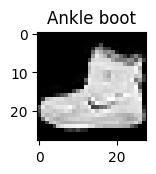

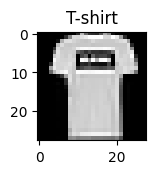

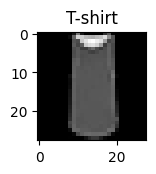

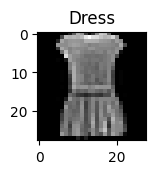

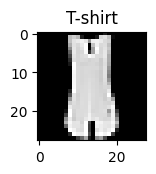

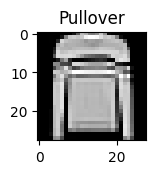

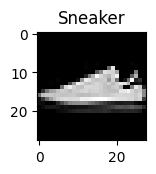

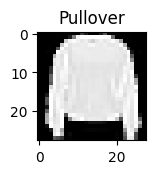

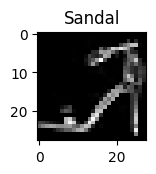

In [ ]:
labels = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i],cmap='gray')
    plt.title(labels[y_train[i]])
plt.show()

In [7]:
arr=np.array([1,2,3,4,5,6,7,8,9,10,11,12])
arr.reshape(-1,12)

array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]])

In [8]:
X_train=X_train.astype("float32")/255
X_test=X_test.astype("float32")/255
X_train=X_train.reshape(-1, 28, 28, 1)
X_test=X_test.reshape(-1, 28, 28, 1)

np.unique(X_train[0:10])


array([0.        , 0.00392157, 0.00784314, 0.01176471, 0.01568628,
       0.01960784, 0.02352941, 0.02745098, 0.03137255, 0.03529412,
       0.03921569, 0.04313726, 0.04705882, 0.05098039, 0.05490196,
       0.05882353, 0.0627451 , 0.06666667, 0.07058824, 0.07450981,
       0.07843138, 0.08235294, 0.08627451, 0.09019608, 0.09411765,
       0.09803922, 0.10196079, 0.10588235, 0.10980392, 0.11372549,
       0.11764706, 0.12156863, 0.1254902 , 0.12941177, 0.13333334,
       0.13725491, 0.14117648, 0.14509805, 0.14901961, 0.15294118,
       0.15686275, 0.16078432, 0.16470589, 0.16862746, 0.17254902,
       0.1764706 , 0.18039216, 0.18431373, 0.1882353 , 0.19215687,
       0.19607843, 0.2       , 0.20392157, 0.20784314, 0.21176471,
       0.21568628, 0.21960784, 0.22352941, 0.22745098, 0.23137255,
       0.23529412, 0.23921569, 0.24313726, 0.24705882, 0.2509804 ,
       0.25490198, 0.25882354, 0.2627451 , 0.26666668, 0.27058825,
       0.27450982, 0.2784314 , 0.28235295, 0.28627452, 0.29019

#BUlid model

In [9]:
model=Sequential()
model.add(Dense(128,activation='relu',input_dim=784))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))


f:\Python314\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# hist=model.fit(
#     X_train,
#     y_train,
#     batch_size=32,
#     epochs=10,
#     validation_split=0.2
#     )

In [12]:
# loss,acc=model.evaluate(X_test,y_test)
# print(loss)

In [13]:
# y_pred=model.predict(X_test)
# print(np.argmax(y_train[0]))

In [14]:
# plt.plot(hist.history['accuracy'])
# plt.plot(hist.history['val_accuracy'])
# plt.legend(["train",'validation'])
# plt.show()

In [15]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [22]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    
)

In [24]:
hist=model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8361 - loss: 0.4646 - val_accuracy: 0.8783 - val_loss: 0.3451
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8880 - loss: 0.3158 - val_accuracy: 0.8876 - val_loss: 0.3096
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9026 - loss: 0.2714 - val_accuracy: 0.9017 - val_loss: 0.2792
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9138 - loss: 0.2396 - val_accuracy: 0.8995 - val_loss: 0.2800
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9221 - loss: 0.2145 - val_accuracy: 0.9038 - val_loss: 0.2744
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9308 - loss: 0.1931 - val_accuracy: 0.9087 - val_loss: 0.2637
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9363 - loss: 0.1740 - val_accuracy: 0.9118 - val_loss: 0.2584
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9421 - los

In [25]:
loss,acc=model.evaluate(X_test,y_test)
print(loss)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9056 - loss: 0.2995
0.29947853088378906


In [26]:
y_pred=model.predict(X_test)
print(np.argmax(y_train[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
0


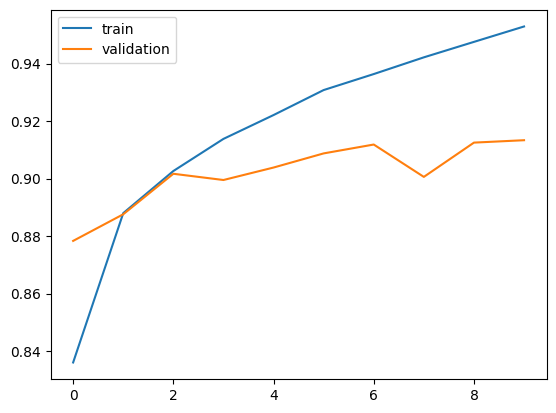

In [27]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.legend(["train",'validation'])
plt.show()

In [28]:
import pickle

data = {
    "X_train": X_train,
    "y_train": y_train,
    "X_test": X_test,
    "y_test": y_test
}

with open("fashion_data.pkl", "wb") as f:
    pickle.dump(data, f)

print("Dataset saved!")

Dataset saved!


In [29]:
model.save("fashion_model.h5")